# 06 - Spatio-Temporal Crime Forecasting

We build two LightGBM forecasters on top of the area/time panels:

* **Daily** — one prediction per (area, day). Inherently noisy.
* **Weekly** — one prediction per (area, week). Lower noise; primary signal for risk.

Both are evaluated against a **naive baseline** (the area's last 28-day mean / last 4-week mean) so we can report a meaningful **skill score** = `1 - mae/naive_mae`.

In [1]:
# bootstrap: make src importable
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import pandas as pd
from pathlib import Path
from src import config, feature_engineering, forecasting
daily = pd.read_parquet(config.DAILY_AREA_PARQUET)
daily = feature_engineering.trim_incomplete_tail(daily)
print('daily panel:', daily.shape, daily['date'].min(), '->', daily['date'].max())

02:08:29 | INFO    | src.feature_engineering | trim_incomplete_tail: cutting at 2024-05-12 (was 2024-06-24)


daily panel: (33474, 8) 2020-01-01 00:00:00 -> 2024-05-12 00:00:00


## Daily forecaster

In [2]:
model, result = forecasting.train_forecaster(daily, horizon_days=28)
print(f'MAE={result.mae:.2f}  RMSE={result.rmse:.2f}  R2={result.r2:.3f}  naive_MAE={result.naive_mae:.2f}  skill={result.skill:+.1%}')

02:08:29 | INFO    | src.forecasting | forecast train=29,834 val=1,232 test=1,260


02:08:29 | INFO    | src.forecasting | [start] fit LightGBM forecaster (h=28d)


02:08:29 | INFO    | src.forecasting | [done ] fit LightGBM forecaster (h=28d) in 0.35s


02:08:29 | INFO    | src.forecasting | forecast MAE=7.79  RMSE=9.48  R2=-0.131  naive_MAE=8.64  skill=+9.8%


MAE=7.79  RMSE=9.48  R2=-0.131  naive_MAE=8.64  skill=+9.8%


## Inspect predicted vs actual for the test window

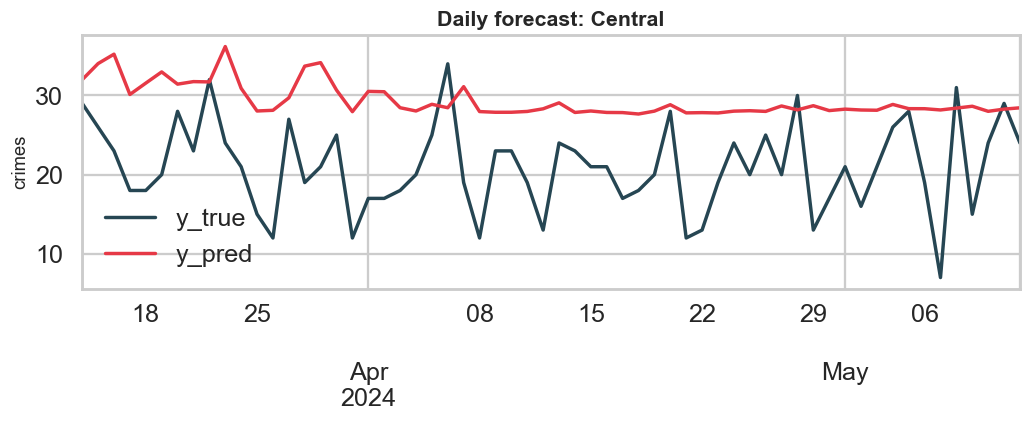

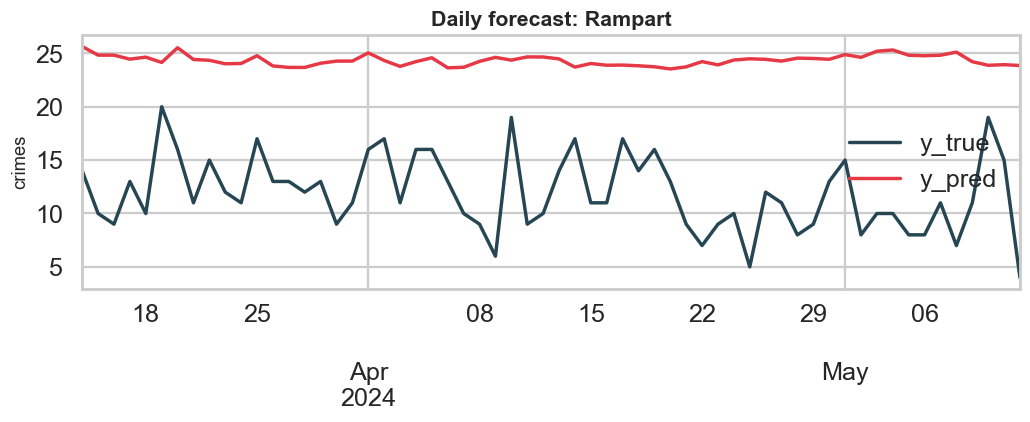

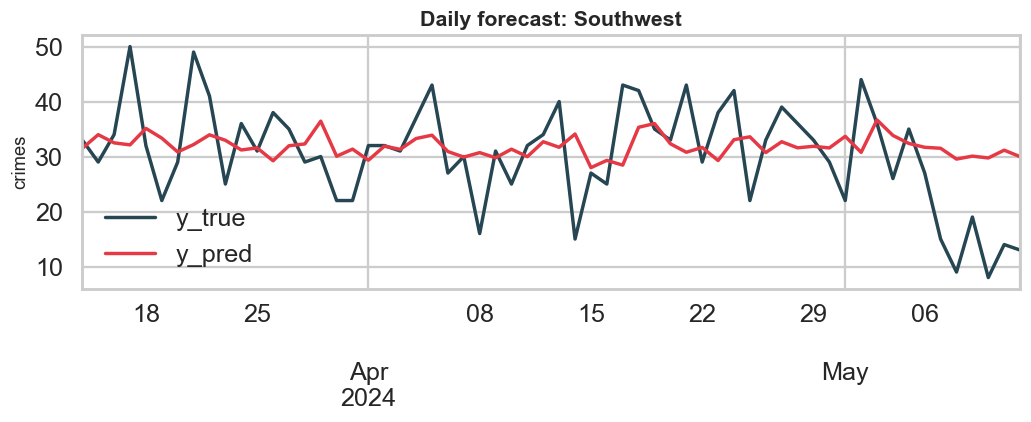

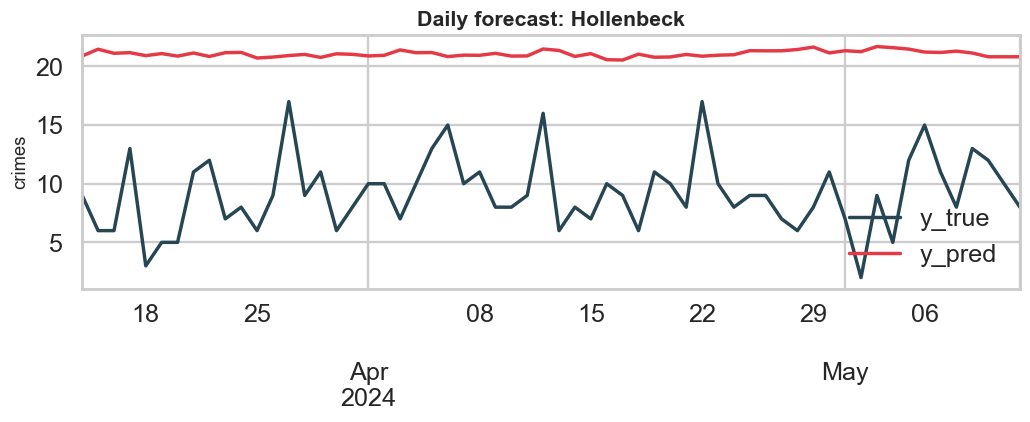

In [3]:
import matplotlib.pyplot as plt
from src.utils import apply_plot_style
apply_plot_style()
preds = result.predictions
for a in preds['area_name'].drop_duplicates().head(4):
    s = preds[preds['area_name']==a].sort_values('date')
    fig, ax = plt.subplots(figsize=(11,3))
    s.plot(x='date', y=['y_true','y_pred'], ax=ax, color=['#264653','#E63946'])
    ax.set_title(f'Daily forecast: {a}'); ax.set_xlabel(''); ax.set_ylabel('crimes');

## Weekly forecaster

In [4]:
weekly = pd.read_parquet(config.WEEKLY_AREA_PARQUET)
weekly = weekly[weekly['date'] <= daily['date'].max() - pd.Timedelta(days=14)]
wmodel, wresult = forecasting.train_weekly_forecaster(weekly)
print(f'MAE={wresult.mae:.2f}  R2={wresult.r2:.3f}  naive_MAE={wresult.naive_mae:.2f}  skill={wresult.skill:+.1%}')

02:08:30 | INFO    | src.forecasting | weekly forecast train=4,014 val=156 test=168


02:08:30 | INFO    | src.forecasting | [start] fit LightGBM weekly forecaster


02:08:30 | INFO    | src.forecasting | [done ] fit LightGBM weekly forecaster in 0.09s


02:08:30 | INFO    | src.forecasting | weekly MAE=40.45  RMSE=53.82  R2=-0.098  naive_MAE=47.73  skill=+15.2%


MAE=40.45  R2=-0.098  naive_MAE=47.73  skill=+15.2%


## Forecast next 7 days

In [5]:
next7 = forecasting.forecast_next_period(daily, model, horizon_days=7)
next7.groupby('area_name')['y_pred'].sum().sort_values(ascending=False).head(10)

C:\Users\cemil\AppData\Local\Temp\ipykernel_23748\652399992.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  next7.groupby('area_name')['y_pred'].sum().sort_values(ascending=False).head(10)


area_name
77th Street    236.642454
Pacific        218.850887
Southwest      215.477621
N Hollywood    203.028832
Central        197.612165
Southeast      192.659106
Hollywood      184.079880
Olympic        181.453301
Newton         177.319344
Van Nuys       175.643079
Name: y_pred, dtype: float64

## Persisted forecast metrics

In [6]:
json.loads(Path('../reports/forecast_metrics.json').read_text())

{'daily': {'horizon_days': 28,
  'MAE': 7.789749803475459,
  'RMSE': 9.483738954097689,
  'MAPE': 0.6149914839402922,
  'R2': -0.13105961971993718,
  'naive_MAE': 8.639002282278879,
  'skill': 0.09830446283658067,
  'test_start': '2024-03-14 00:00:00',
  'test_end': '2024-05-12 00:00:00'},
 'weekly': {'horizon_weeks': 8,
  'MAE': 40.45229354219827,
  'RMSE': 53.82112796077305,
  'MAPE': 0.3869894442254762,
  'R2': -0.09802617778199507,
  'naive_MAE': 47.72767857142857,
  'skill': 0.15243534248878376,
  'test_start': '2024-03-04 00:00:00',
  'test_end': '2024-04-22 00:00:00'}}